In [1]:
# Amazon Review Regret Predictor

## Objective
#This project predicts whether a customer regrets a purchase based on Amazon reviews.

## Approach
#Used TF-IDF for text features
#Created custom target variable "Regret"
#Added feature: review length
#Trained ML models to classify regret

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "//content//Reviews.csv",
    engine='python',
    on_bad_lines='skip'
)

In [4]:
df = df[['Score', 'Text']].dropna()

In [5]:
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
df = df.dropna(subset=['Score'])
df = df[df['Score'].isin([1,2,3,4,5])]

In [6]:
df

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...
...,...,...
88955,2,"I purchased the ""Organic"" variety of this bran..."
88956,4,"Because we were having guests for a visit, I o..."
88957,5,Coffee People's Tree Hugger Coffee is the favo...
88958,5,"Great coffee, and I feel good knowing it's fai..."


In [7]:
def create_regret(score):
    if score <= 2:
        return 1
    elif score >= 4:
        return 0
    else:
        return None

df['Regret'] = df['Score'].apply(create_regret)
df = df.dropna()

In [8]:
#Reduce Data (for speed)
df = df.sample(20000, random_state=42)

In [9]:
df

,Score,Text,Regret
41637,4,I've tried MaraNatha's peanut butter and almon...,0.0
33570,5,"One of the best flavor K-Cups available. Fast,...",0.0
25535,5,"My dogs are picky but they do eat Canidae, not...",0.0
27679,5,"Like others have mentioned, yogurt made with t...",0.0
17653,5,I bought this when I realized that Splenda con...,0.0
...,...,...,...
40366,5,I use this seasoning in a mixture with brown s...,0.0
66784,4,Nature's Path Love Crunch Premium Organic Gran...,0.0
65972,4,I purchased Zuke's mini naturals in the Chicke...,0.0
11603,5,"You can't find these bad boys in Kentucky, so ...",0.0


In [10]:
#Feature Engineering
df['review_length'] = df['Text'].apply(len)

In [11]:
#EDA
print(df.shape)
df.info()
df.describe()

(20000, 4)
<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 41637 to 88431
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Score          20000 non-null  int64  
 1   Text           20000 non-null  object 
 2   Regret         20000 non-null  float64
 3   review_length  20000 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 781.2+ KB


,Score,Regret,review_length
count,20000.000000,20000.000000,20000.000000
mean,4.245400,0.164700,431.721900
std,1.339914,0.370919,446.456275
min,1.000000,0.000000,39.000000
25%,4.000000,0.000000,180.000000
50%,5.000000,0.000000,301.000000
75%,5.000000,0.000000,524.000000
max,5.000000,1.000000,16952.000000


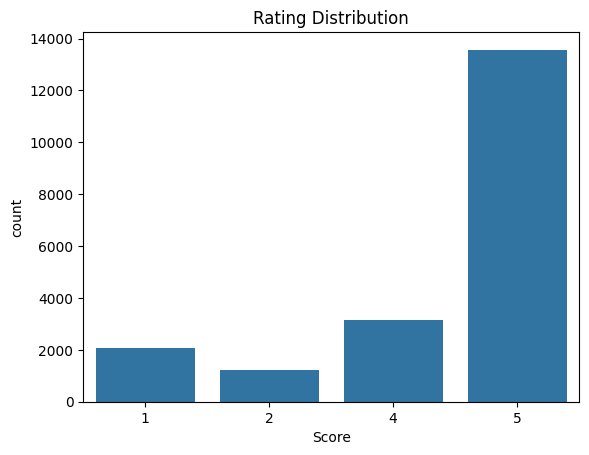

In [12]:
#Rating Distribution
sns.countplot(x='Score', data=df)
plt.title("Rating Distribution")
plt.show()

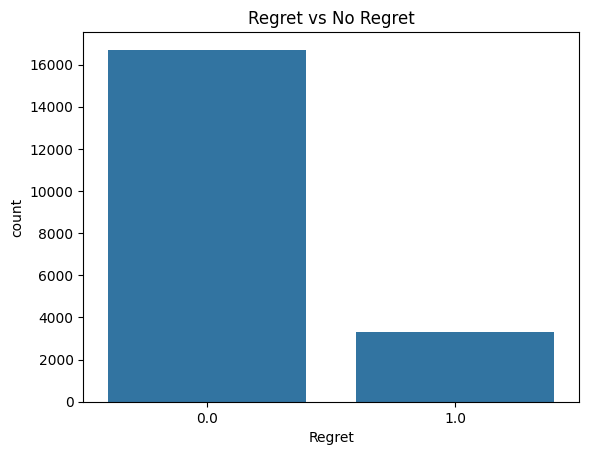

In [13]:
#Regret Distribution
sns.countplot(x='Regret', data=df)
plt.title("Regret vs No Regret")
plt.show()

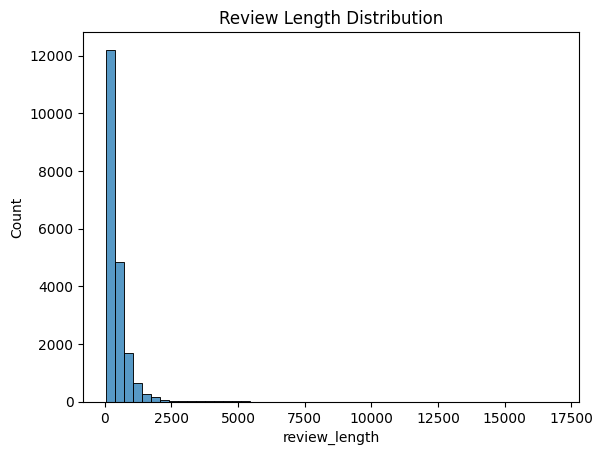

In [14]:
#Review Length Distribution
sns.histplot(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

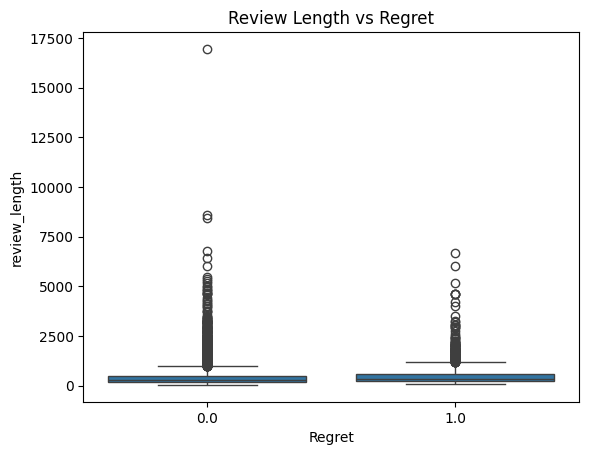

In [15]:
#Review Length vs Regret
sns.boxplot(x='Regret', y='review_length', data=df)
plt.title("Review Length vs Regret")
plt.show()

<Axes: >

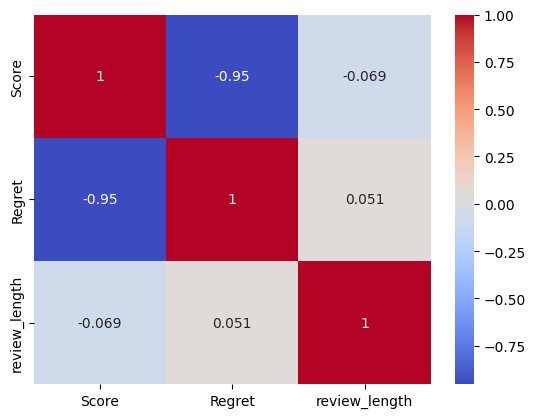

In [16]:
sns.heatmap(
    df[['Score','Regret','review_length']].corr(),
    annot=True,
    cmap='coolwarm'
)

In [17]:
#Text Processing (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

X_text = tfidf.fit_transform(df['Text']).toarray()

In [18]:
#Combine Features
X = np.hstack((X_text, df[['review_length']].values))

In [19]:
#Target
y = df['Regret']

In [20]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
#Prediction
y_pred = rf.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8775

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.99      0.93      3322
         1.0       0.89      0.32      0.47       678

    accuracy                           0.88      4000
   macro avg       0.88      0.65      0.70      4000
weighted avg       0.88      0.88      0.85      4000



In [24]:
#Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[3295   27]
 [ 463  215]]
              precision    recall  f1-score   support

         0.0       0.88      0.99      0.93      3322
         1.0       0.89      0.32      0.47       678

    accuracy                           0.88      4000
   macro avg       0.88      0.65      0.70      4000
weighted avg       0.88      0.88      0.85      4000

Accuracy: 0.8775


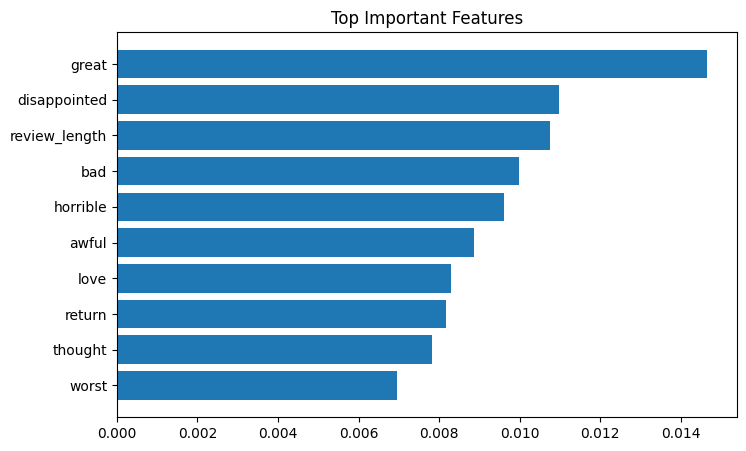

In [25]:
#Feature Importance
importances = rf.feature_importances_

# TF-IDF feature names
tfidf_features = tfidf.get_feature_names_out()

# Add extra feature name
all_features = np.append(tfidf_features, ['review_length'])

# Get top indices
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(all_features[indices], importances[indices])
plt.title("Top Important Features")
plt.show()

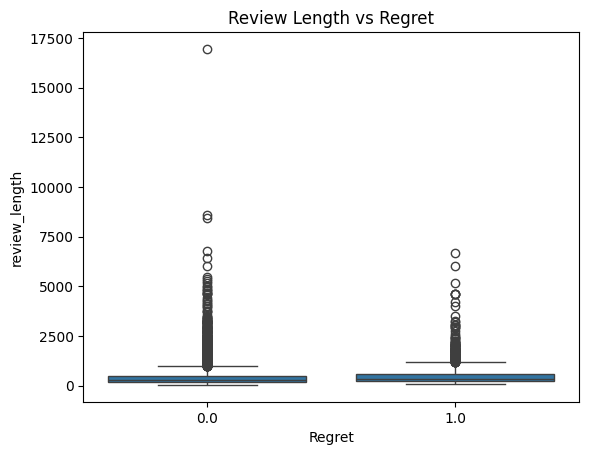

In [26]:
#Final Insight Graph
sns.boxplot(x='Regret', y='review_length', data=df)
plt.title("Review Length vs Regret")
plt.show()

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))


Random Forest
Accuracy: 0.876

Logistic Regression
Accuracy: 0.89125

Naive Bayes
Accuracy: 0.85925


In [28]:
## Conclusion

#Logistic Regression achieved the highest accuracy of 89.12%
#Random Forest and Naive Bayes also performed well but slightly lower
#TF-IDF helped convert text into useful features
#Simple models performed better on this dataset

## Business Use

#Identify unhappy customers early
#Reduce product returns
#Improve customer satisfaction

In [29]:
## Why Logistic Regression Performed Best

##TF-IDF creates high-dimensional sparse data, where linear models like Logistic Regression perform better than complex models like Random Forest.